### 01_pretratamiento.ipynb

In [5]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.impute import KNNImputer

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Definiendo constantes

In [6]:
INITIAL_GRAPH_BASE_PATH = Path("./graphs/initial/")


In [15]:
# Leyendo base de datos en formato .csv, convirtiendola en pandas dataframe
raw_data = pd.read_csv('../data/raw/raw_data.csv', delimiter=",")
display(raw_data.head())
display(raw_data.info())

,fecha,referencia,alcalinidad_total,aluminio,bario,bicarbonatos,cadmio,calcio,carbonatos,cianuro_libre,...,solidos_sedimentables,solidos_suspendidos,solidos_totales,solidos_totales_volátiles,sulfatos,sulfuros,sustancias_solubles_al_hexano,turbiedad,zinc,obs
0,04/06/2001,P1,154.80,NaN,NaN,NaN,0.50,NaN,NaN,NaN,...,0.3,41,313,NaN,10.65,NaN,0.0,17,0.1353,NaN
1,04/06/2001,P2,161.90,NaN,NaN,NaN,0.50,NaN,NaN,NaN,...,0.9,185,453,NaN,16.36,NaN,18.0,40,0.09056,NaN
2,04/06/2001,P3,160.90,NaN,NaN,NaN,0.50,NaN,NaN,NaN,...,0.7,209,470,NaN,18.33,NaN,15.0,52,0.09999,NaN
3,04/06/2001,P4,159.70,NaN,NaN,NaN,0.50,NaN,NaN,NaN,...,0.2,74,350,NaN,23.95,NaN,6.0,26,0.09698,NaN
4,04/07/2001,P1,153.70,169.7,NaN,NaN,0.50,NaN,NaN,NaN,...,0,0,293,NaN,0,NaN,14.5,NaN,0.1172,NaN


<class 'pandas.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   fecha                          640 non-null    str    
 1   referencia                     640 non-null    str    
 2   alcalinidad_total              93 non-null     str    
 3   aluminio                       233 non-null    str    
 4   bario                          12 non-null     str    
 5   bicarbonatos                   71 non-null     str    
 6   cadmio                         404 non-null    str    
 7   calcio                         13 non-null     str    
 8   carbonatos                     71 non-null     str    
 9   cianuro_libre                  121 non-null    float64
 10  cloruros                       27 non-null     str    
 11  cobre                          374 non-null    str    
 12  coliformes_termotolerantes     550 non-null    str    
 13  c

None

### Ajuste de descriptores (columnas de datos)

#### Analisis porcentaje optimo de nulos por descriptor.

In [16]:
def acceptable_nullvalues(data: pd.DataFrame, range_umbral: np.ndarray, output_path: Path, show: bool = True) -> None:
    """
    Analiza cómo varía el número de columnas retenidas al aplicar diferentes umbrales
    de valores no nulos por columna.
    
    Esta función permite evaluar el impacto de eliminar columnas con alta proporción
    de valores nulos, ayudando a decidir un umbral adecuado para el preprocesamiento
    de datos.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame original que contiene los datos a analizar, incluyendo
        posibles valores nulos (NaN).
    
    range_umbral : np.ndarray
        Array con los umbrales a evaluar, donde cada valor representa la proporción
        mínima de valores NO nulos que debe tener una columna para ser retenida.
        Debe estar en el rango [0, 1].
        Ejemplo: np.array([0.5, 0.6, 0.7, 0.8, 0.9]) 
        - 0.5 significa: retener columnas con al menos 50% de datos no nulos
        - 0.9 significa: retener columnas con al menos 90% de datos no nulos
    
    show : bool, default=False
        Si es True, muestra una gráfica con la evolución del número de columnas
        retenidas según el umbral aplicado. Si es False, solo calcula los resultados
        sin mostrar visualización.
    
    Returns
    -------
    None
        La función no retorna ningún valor, pero si show=True genera y muestra
        una gráfica. Los resultados intermedios se almacenan en la variable local
        columns_per_perc.
    
    Notes
    -----
    - Funciona eliminando columnas que NO alcanzan el mínimo de valores no nulos
    - La función dropna(thresh=umbral_len, axis=1) elimina columnas (axis=1)
      que tienen menos de 'umbral_len' valores NO nulos
    - El umbral_len se calcula como: len(data) * umbral (número mínimo de no nulos)
    
    Examples
    --------
    >>> import pandas as pd
    >>> import numpy as np
    >>> 
    >>> # Crear datos de ejemplo con valores nulos
    >>> df = pd.DataFrame({
    ...     'col1': [1, 2, 3, 4, 5],
    ...     'col2': [1, np.nan, 3, np.nan, 5],
    ...     'col3': [np.nan, np.nan, np.nan, np.nan, np.nan]
    ... })
    >>> 
    >>> # Evaluar diferentes umbrales
    >>> umbrales = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    >>> acceptable_nullvalues(df, umbrales, show=True)
    """
    
    # 1. Inicializar matriz para almacenar resultados
    # La matriz tendrá tantas filas como umbrales evaluados y 2 columnas:
    # - Columna 0: valor del umbral (proporción de no nulos requerida)
    # - Columna 1: número de columnas que cumplen con ese umbral
    columns_per_perc = np.zeros([len(range_umbral), 2])
    
    # 2. Evaluar cada umbral
    i = 0  # Contador para indexar la matriz de resultados
    
    for umbral in range_umbral:
        # 2.1 Calcular el número mínimo de valores NO nulos requeridos
        #     Ejemplo: Si el DataFrame tiene 100 filas y umbral=0.5,
        #     entonces umbral_len = 100 * 0.5 = 50 (necesita al menos 50 no nulos)
        umbral_len = len(data) * umbral
        
        # 2.2 Eliminar columnas que NO cumplen con el umbral
        #     - data.copy(): trabaja sobre una copia para no modificar el original
        #     - dropna(thresh=umbral_len, axis=1): 
        #         * thresh: número mínimo de valores NO nulos requeridos por columna
        #         * axis=1: aplica sobre columnas (no filas)
        #         * Elimina columnas que tienen menos de 'umbral_len' valores no nulos
        data_fixed_test = data.copy().dropna(thresh=umbral_len, axis=1)
        
        # 2.3 Almacenar resultados
        #     - Columna 0: el umbral evaluado
        #     - Columna 1: cantidad de columnas que sobreviven después de la limpieza
        columns_per_perc[i, 0] = umbral
        columns_per_perc[i, 1] = len(data_fixed_test.columns)
        
        # 2.4 Avanzar al siguiente índice
        i += 1
    
    # 3. Visualización opcional de resultados
    if show:
        # 3.1 Crear una nueva figura con tamaño personalizado (ancho=8, alto=4 pulgadas)
        plt.figure(figsize=(8, 4))
        
        # 3.2 Graficar la evolución del número de columnas vs umbral
        #     '--.' : estilo de línea (guiones-puntos) para mejor visualización
        plt.plot(columns_per_perc[:, 0], columns_per_perc[:, 1], '--.')
        
        # 3.3 Activar marcas menores en los ejes (para mayor precisión visual)
        plt.minorticks_on()
        
        # 3.4 Configurar cuadrícula
        #     - which='major': solo para marcas principales (las que tienen etiqueta)
        #     - linestyle='--': línea punteada
        #     - linewidth='0.5': grosor fino
        #     - color='gray': color gris suave
        plt.grid(which='major', linestyle='--', linewidth='0.5', color='gray')
        
        # 3.5 Configurar títulos y etiquetas de ejes
        plt.title("Columnas por porcentaje")
        plt.xlabel("Porcentaje no nulos")  # Umbral de valores NO nulos requerido
        plt.ylabel("Columnas numéricas seleccionadas")  # Cantidad de columnas retenidas
        
        # 3.6 Ajustar diseño para evitar solapamiento de elementos
        plt.tight_layout()
        
        # 3.7 Mostrar la gráfica en pantalla
        plt.savefig(output_path, bbox_inches='tight')
        plt.show()

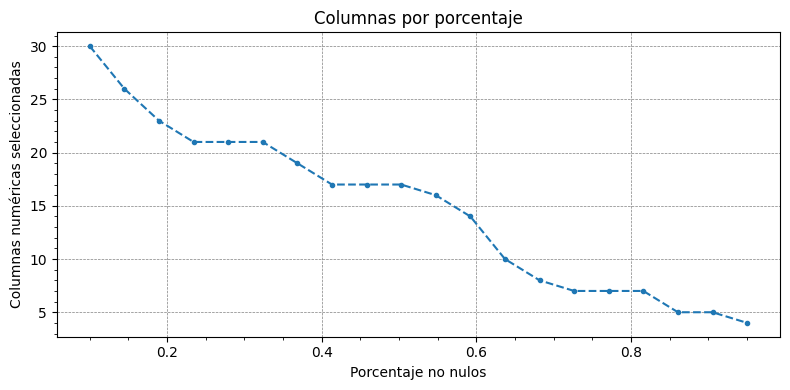

In [9]:
range_umbral = np.linspace(0.1,0.95,20)
acceptable_nullvalues(raw_data, range_umbral, INITIAL_GRAPH_BASE_PATH / "umbral_nulos.png",)

#### Modificación: Descarte de descriptores poco relevantes

In [10]:
# Ajustes de base de datos
from typing import List


def clean_dataframe_by_treshold(data: pd.DataFrame, excluded_cols: List[str], threshold: float = 0.5, show: bool = True) -> pd.DataFrame:
    """
    Limpia un DataFrame convirtiendo columnas a formato numérico y eliminando 
    aquellas con excesivos valores nulos.
    
    Esta función realiza dos pasos principales de limpieza:
    1. Convierte columnas de texto a valores numéricos (manejando formatos como "1,234.56")
    2. Elimina columnas que superan un umbral de valores nulos
    
    Es especialmente útil cuando se trabaja con datos provenientes de archivos CSV
    o Excel donde los números pueden estar almacenados como texto con comas decimales.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame original que contiene los datos a limpiar, incluyendo
        posibles columnas numéricas en formato texto.
    
    excluded_cols : List[str]
        Lista con los nombres de las columnas que NO deben ser convertidas
        a numérico. Útil para columnas categóricas, fechas o identificadores.
        Ejemplo: ['id', 'fecha', 'categoria']
    
    threshold : float, default=0.5
        Umbral de tolerancia para valores nulos (NaN) por columna.
        Representa la proporción MÁXIMA de nulos permitida.
        - threshold=0.5: elimina columnas con más del 50% de valores nulos
        - threshold=0.2: elimina columnas con más del 20% de valores nulos (más estricto)
        - threshold=0.9: elimina columnas con más del 90% de valores nulos (más permisivo)
        
        El valor debe estar en el rango [0, 1].
    
    show : bool, default=True
        Si es True, muestra información del DataFrame limpio usando:
        - head(): primeras 5 filas
        - info(): resumen de tipos de datos y memoria
        Si es False, no muestra nada y solo retorna el DataFrame limpio.
    
    Returns
    -------
    pd.DataFrame
        DataFrame limpio con:
        - Columnas excluidas preservadas (sin modificar)
        - Columnas convertidas a tipo numérico (float64/int64)
        - Columnas con excesivos nulos eliminadas
        
        Nota: Los valores que no pudieron convertirse a número se convierten en NaN.
    
    Notes
    -----
    - La conversión numérica asume que los números pueden tener:
        * Comas como separadores de miles (se eliminan)
        * Puntos como separadores decimales
        * Formato: "1,234.56" → 1234.56
        * Formato: "1234.56" → 1234.56
    
    - El umbral se aplica a TODAS las columnas numéricas convertidas,
      pero las columnas excluidas se conservan siempre.
    
    Examples
    --------
    >>> import pandas as pd
    >>> 
    >>> # Crear datos de ejemplo
    >>> df = pd.DataFrame({
    ...     'id': [1, 2, 3, 4, 5],
    ...     'ventas': ['1,234.56', '2,345.67', 'N/A', '4,567.89', '5,678.90'],
    ...     'costos': ['123.45', '234.56', '345.67', '456.78', '567.89'],
    ...     'categoria': ['A', 'B', 'C', 'D', 'E'],
    ...     'gasto_invalido': [100, None, None, None, 500]  # 60% nulos
    ... })
    >>> 
    >>> # Limpiar datos
    >>> df_limpio = clean_dataframe_by_treshold(
    ...     data=df,
    ...     excluded_cols=['id', 'categoria'],
    ...     threshold=0.5,
    ...     show=True
    ... )
    >>> 
    >>> # Resultado: 'gasto_invalido' se elimina por tener >50% nulos
    """
    
    # 1. Preparar copia de trabajo y excluir columnas especificadas
    # Creamos una copia para no modificar el DataFrame original
    pre_data = data.copy()
    
    # Identificar columnas que NO están en la lista de exclusión
    # Estas son las columnas que intentaremos convertir a numérico
    # axis=0 se refiere a columnas (aunque por defecto es axis=1, se mantiene claridad)
    cols_a_limpiar = pre_data.drop(columns=excluded_cols).columns
    
    # 2. Conversión de texto a números
    # Procesamos cada columna candidata individualmente
    for col in cols_a_limpiar:
        # 2.1 Convertir la columna a string (por si acaso hay números o nulos)        
        # Convertir a string primero para manejar valores no string
        col_as_string = pre_data[col].astype(str)
        
        # Reemplazar comas (separadores de miles) por puntos
        col_without_commas = col_as_string.str.replace(',', '.', regex=False)
        
        # Extraer el patrón numérico (number with optional decimal)
        extracted_number = col_without_commas.str.extract(r'(\d+\.?\d*)')[0]
        
        # Convertir a número, forzando errores a NaN
        pre_data[col] = pd.to_numeric(extracted_number, errors='coerce')
        
        # Nota: La versión original combina todos estos pasos en una sola línea
        # Se ha desglosado aquí para claridad en los comentarios
    
    # 3. Eliminar columnas con excesivos valores nulos
    # Calcular el número mínimo de valores NO nulos requeridos por columna
    # Ejemplo: Si el DataFrame tiene 100 filas y threshold=0.5
    # entonces umbral = 100 * 0.5 = 50 valores NO nulos necesarios
    
    umbral = int(len(pre_data) * threshold)
    
    # Aplicar eliminación de columnas:
    # - dropna(thresh=umbral, axis=1): elimina columnas (axis=1)
    #   que tienen MENOS de 'umbral' valores NO nulos
    # - threshold=0.5 significa: eliminar columnas con más de 50% de nulos
    #   (equivalente a menos de 50% de no nulos)
    
    pre_data = pre_data.dropna(thresh=umbral, axis=1)
    
    # 4. Mostrar información si se solicita
    if show:
        print(pre_data.head())  # Muestra primeras 5 filas para vista previa
        pre_data.info()  # Muestra tipos de datos, memoria, columnas no nulas
        
    return pre_data

In [11]:
EXCLUDED_COLS = ['fecha', 'referencia', 'obs']

pre_data = clean_dataframe_by_treshold(raw_data, EXCLUDED_COLS)

        fecha referencia  cadmio  cobre  coliformes_termotolerantes  \
0  04/06/2001         P1     0.5   1.00                      3000.0   
1  04/06/2001         P2     0.5   1.00                      2200.0   
2  04/06/2001         P3     0.5   1.00                      7000.0   
3  04/06/2001         P4     0.5   1.00                     11000.0   
4  04/07/2001         P1     0.5   2.89                     13000.0   

   coliformes_totales  cromo  dbo5    dqo  hierro  manganeso  niquel    ph  \
0              3000.0    2.0  0.68  11.81   1.883    0.05285     4.0  8.20   
1              7000.0    2.0  0.18  23.42   5.179    0.16410     4.0  8.36   
2             17000.0    2.0  0.48  19.68   6.043    0.20470     4.0  8.47   
3             11000.0    2.0  0.58   7.87   3.159    0.09761     4.0  8.34   
4             13000.0    2.0  0.35   7.75   1.093    0.03675     5.2  8.44   

   plomo  solidos_suspendidos  solidos_totales     zinc  
0   10.0                 41.0            313.0

In [12]:
# 3. Imputar nulos restantes con la mediana (simple y robusto)
# data_fixed = data_fixed.fillna(data.median(numeric_only=True))

def impute_data_knn(data: pd.DataFrame, show: bool = True) -> pd.DataFrame:
    """
    Imputa (rellena) valores nulos en un DataFrame utilizando el algoritmo KNN.
    
    Esta función utiliza el método de K-Nearest Neighbors (KNN) para estimar 
    y rellenar los valores faltantes en las columnas numéricas del DataFrame.
    El algoritmo encuentra las k muestras más similares y promedia sus valores
    para imputar cada dato faltante.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame que contiene valores nulos (NaN) en sus columnas numéricas.
        Las columnas no numéricas (como 'fecha' y 'referencia') se conservan
        pero no se imputan.
    
    show : bool, default=True
        Si es True, muestra las primeras 5 filas del DataFrame después de la imputación.
        Si es False, no muestra nada y solo retorna el DataFrame limpio.
    
    Returns
    -------
    pd.DataFrame
        DataFrame con los valores nulos imputados en las columnas numéricas.
        Las columnas no numéricas ('fecha' y 'referencia') se mantienen
        sin modificación y se añaden al final del DataFrame resultante.
    
    Notes
    -----
    - El algoritmo KNN imputa valores basándose en la distancia entre muestras
    - Por defecto usa n_neighbors=5 (considera los 5 vecinos más cercanos)
    - Solo se imputan columnas numéricas (int, float)
    - Las columnas 'fecha' y 'referencia' se conservan sin cambios
    - El imputador KNN funciona mejor con datos escalados/normalizados
    
    Important
    ---------
    Esta función asume que las columnas 'fecha' y 'referencia' existen en el
    DataFrame original. Si no existen, causará un KeyError. Además, solo
    preserva estas dos columnas no numéricas; otras columnas no numéricas
    se perderán en el proceso.
    
    Examples
    --------
    >>> import pandas as pd
    >>> import numpy as np
    >>> 
    >>> # Crear datos de ejemplo con valores nulos
    >>> df = pd.DataFrame({
    ...     'temperatura': [36.5, 37.2, np.nan, 36.8, 38.1, np.nan],
    ...     'humedad': [65, 70, 68, np.nan, 72, 71],
    ...     'presion': [1013, 1012, 1014, np.nan, 1011, 1015],
    ...     'fecha': ['2024-01-01', '2024-01-02', '2024-01-03', 
    ...               '2024-01-04', '2024-01-05', '2024-01-06'],
    ...     'referencia': ['A', 'B', 'C', 'D', 'E', 'F']
    ... })
    >>> 
    >>> # Imputar valores nulos
    >>> df_imputed = impute_data_knn(df, show=True)
    >>> 
    >>> # Verificar que los nulos fueron imputados
    >>> print(df_imputed.isna().sum())
    temperatura    0
    humedad        0
    presion        0
    fecha          0
    referencia     0
    dtype: int64
    
    See Also
    --------
    sklearn.impute.KNNImputer : Implementación base del algoritmo KNN para imputación
    SimpleImputer : Imputación más simple usando media, mediana o moda
    """
    
    # 1. Configurar el imputador KNN
    # KNNImputer: Completa valores nulos usando los k vecinos más cercanos
    imputer = KNNImputer(n_neighbors=5)
    
    # 2. Identificar columnas numéricas del DataFrame
    # select_dtypes(include=[np.number]): Filtra columnas numéricas  
    cols_numericas = data.select_dtypes(include=[np.number]).columns
    
    # Verificar si hay columnas numéricas para imputar
    if len(cols_numericas) == 0:
        print("Advertencia: No se encontraron columnas numéricas para imputar")
        return data
    
    print(f"Imputando {len(cols_numericas)} columnas numéricas: {list(cols_numericas)}")
    
    # 3. Aplicar imputación KNN
    # Solo imputamos las columnas numéricas para:
    #   1. Mejorar rendimiento (menos columnas a procesar)
    #   2. Evitar errores con datos no numéricos
    #   3. KNN funciona mejor con datos numéricos
    
    # fit_transform realiza dos operaciones:
    #   - fit(): Aprende la estructura de los datos (distancias entre muestras)
    #   - transform(): Aplica la imputación rellenando los nulos
    data_imputed_array = imputer.fit_transform(data[cols_numericas])
    
    # 4. Reconstruir DataFrame con estructura original
    # Convertir el array resultante de vuelta a DataFrame
    # Mantenemos los mismos nombres de columna que tenían las columnas numéricas
    data_imputed = pd.DataFrame(data_imputed_array, columns=cols_numericas)
    
    # 5. Recuperar columnas no numéricas preservadas
    # NOTA IMPORTANTE: Este código asume que las columnas 'fecha' y 'referencia'
    # existen y deben ser preservadas tal como están (sin imputación)
    # 
    # Si el DataFrame original contiene otras columnas no numéricas
    # (como 'categoria', 'ciudad', etc.), estas se perderán.
    
    # Verificar que las columnas existen antes de intentar agregarlas
    if 'fecha' in data.columns:
        data_imputed['fecha'] = data['fecha'].values
    else:
        print("Advertencia: La columna 'fecha' no existe en el DataFrame original")
    
    if 'referencia' in data.columns:
        data_imputed['referencia'] = data['referencia'].values
    else:
        print("Advertencia: La columna 'referencia' no existe en el DataFrame original")
    
    # 6. Mostrar resultados si se solicita
    if show:
        # Mostrar primeras 5 filas del DataFrame imputado
        print(data_imputed.head())
        
        # Mostrar estadísticas de imputación
        print(f"Columnas imputadas: {len(cols_numericas)}")
        print(f"Total de valores nulos después de imputación: {data_imputed[cols_numericas].isna().sum().sum()}")
    
    return data_imputed

In [13]:
pre_data = impute_data_knn(pre_data)
pre_data.describe()

Imputando 15 columnas numéricas: ['cadmio', 'cobre', 'coliformes_termotolerantes', 'coliformes_totales', 'cromo', 'dbo5', 'dqo', 'hierro', 'manganeso', 'niquel', 'ph', 'plomo', 'solidos_suspendidos', 'solidos_totales', 'zinc']
   cadmio  cobre  coliformes_termotolerantes  coliformes_totales  cromo  dbo5  \
0     0.5   1.00                      3000.0              3000.0    2.0  0.68   
1     0.5   1.00                      2200.0              7000.0    2.0  0.18   
2     0.5   1.00                      7000.0             17000.0    2.0  0.48   
3     0.5   1.00                     11000.0             11000.0    2.0  0.58   
4     0.5   2.89                     13000.0             13000.0    2.0  0.35   

     dqo  hierro  manganeso  niquel    ph  plomo  solidos_suspendidos  \
0  11.81   1.883    0.05285     4.0  8.20   10.0                 41.0   
1  23.42   5.179    0.16410     4.0  8.36   10.0                185.0   
2  19.68   6.043    0.20470     4.0  8.47   10.0                209

,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc
count,640.000000,640.000000,6.400000e+02,6.400000e+02,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000,640.000000
mean,14.945254,50.972653,1.111112e+05,2.245199e+05,222.014667,44.845339,29.829776,21.506911,3.010868,188.338541,7.967491,81.254654,248.138319,195.382812,1.678771
std,28.085134,63.426422,5.478182e+05,1.018455e+06,228.670163,127.050159,74.084513,35.624892,8.169757,163.875110,0.562597,72.018414,231.020017,637.955896,13.490251
min,0.500000,1.000000,1.600000e+00,1.600000e+00,1.020000,0.000000,1.085000,0.003000,0.001000,1.117000,5.480000,1.026000,0.000000,2.164000,0.000800
25%,10.000000,10.000000,9.300000e+02,2.400000e+03,20.000000,1.000000,9.133800,1.657500,0.068975,50.000000,7.720000,50.000000,35.250000,14.611100,0.044550
50%,10.000000,33.555000,3.300000e+03,1.300000e+04,163.200000,3.461500,20.237500,10.501800,0.620000,170.860000,8.080000,60.375000,224.000000,18.510000,0.488140
75%,15.413470,59.165000,2.496500e+04,5.400000e+04,355.738000,14.545000,28.363650,28.238200,1.916500,296.100000,8.340000,97.100000,372.480000,341.188700,1.333500
max,482.800000,569.140000,1.100000e+07,1.700000e+07,989.200000,990.000000,891.000000,394.000000,84.600000,970.400000,9.080000,670.400000,2320.000000,13710.000000,332.000000


In [14]:
# Guardando en formato .csv
pre_data.to_csv("../data/processed/data_fixed.csv", index=False)

### Algunos graficos del dataframe procesado

In [ ]:
from pathlib import Path

def empty_directory(directory_path):
    """
    Verifica si un directorio está vacío.
    
    Parameters
    ----------
    directory_path : str o Path
        Ruta del directorio a verificar
    
    Returns
    -------
    bool
        True si el directorio está vacío, False si contiene archivos o carpetas
    
    Raises
    ------
    ValueError
        Si la ruta no corresponde a un directorio
    """
    
    # Convertir la ruta a objeto Path para usar sus métodos
    path = Path(directory_path)
    
    # Verificar si la ruta existe y es un directorio
    if path.is_dir():
        # any(path.iterdir()) es True si hay al menos un archivo/carpeta
        # not lo invierte: True si está vacío, False si tiene contenido
        return not any(path.iterdir())
    else:
        # Si no es un directorio, lanzar error
        raise ValueError("This path is not a directory")


In [ ]:
def pfqb_graphs(data_fixed: pd.DataFrame, output_path: str) -> None:
    """
    Genera gráficos exploratorios para cada columna numérica del DataFrame.
    
    Para cada columna numérica, crea 4 gráficos:
    - Histograma (distribución)
    - Boxplot (valores atípicos por referencia)
    - Scatterplot (tendencia temporal)
    - KDE (densidad apilada por referencia)
    
    Parameters
    ----------
    data_fixed : pd.DataFrame
        DataFrame limpio que debe contener las columnas 'fecha' y 'referencia'
    
    output_path : str
        Ruta donde se guardarán los gráficos (se tomará el directorio padre)
    
    Returns
    -------
    None
        La función guarda los gráficos en './graphs/initial/' y los muestra
    """
    
    # Obtener el directorio donde se guardarán los gráficos
    # Ejemplo: si output_path = "./graphs/initial/graf1.png", toma "./graphs/initial"
    directory_path = Path(output_path).parent

    try:
        # Verificar si el directorio está vacío (para no sobrescribir archivos)
        if empty_directory(directory_path):
            
            # Excluir columnas 'fecha' y 'referencia' (son las que usamos para agrupar)
            # Solo graficamos columnas numéricas
            column_names = data_fixed.drop(columns=['fecha', 'referencia']).columns.to_list()

            # Generar un gráfico compuesto para cada columna numérica
            for column_name in column_names:

                # Crear figura con 2 filas y 2 columnas (total 4 gráficos por página)
                fig_1, axes_1 = plt.subplots(2, 2, figsize=(10, 8))
                
                # Gráfico 1: Histograma (fila 0, columna 0)
                # Muestra la distribución de los valores
                sns.histplot(data=data_fixed, x=column_name, ax=axes_1[0, 0])
                
                # Gráfico 2: Boxplot (fila 0, columna 1)
                # Muestra mediana, cuartiles y valores atípicos por 'referencia'
                sns.boxplot(data=data_fixed, x='referencia', y=column_name, ax=axes_1[0, 1])
                
                # Gráfico 3: Scatterplot (fila 1, columna 0)
                # Muestra evolución temporal de los valores
                sns.scatterplot(data=data_fixed, x='fecha', y=column_name, ax=axes_1[1, 0])
                
                # Gráfico 4: KDE (fila 1, columna 1)
                # Densidad de probabilidad apilada por 'referencia'
                sns.kdeplot(
                    data=data_fixed,
                    x=column_name,
                    bw_adjust=1,           # Suavizado de la curva
                    hue="referencia",      # Colorea por categoría
                    multiple="stack",      # Apila las áreas
                    ax=axes_1[1, 1],
                )

                # Formatear eje X del gráfico temporal (scatterplot)
                # Mostrar fechas como Año-Mes (ej: 2024-01)
                axes_1[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
                axes_1[1, 0].xaxis.set_major_locator(mdates.MonthLocator())

                # Limpiar etiqueta del eje X en el KDE (no es necesaria)
                axes_1[1, 1].set(xlabel=None)

                # Rotar etiquetas de todos los ejes X para mejor legibilidad
                for ax in axes_1.flat:
                    ax.tick_params(axis='x', rotation=45, labelsize=8)

                # Ajustar diseño para que no se superpongan los elementos
                plt.tight_layout()
                
                # Guardar gráfico con nombre basado en la columna
                plt.savefig(f'./graphs/initial/initial_{column_name}.png')
                
                # Mostrar gráfico en pantalla
                plt.show()
        else:
            # El directorio no está vacío, no se deben guardar gráficos
            print(f"This directory {directory_path} is not empty. Choose another one.")
            
    except ValueError as e:
        # Capturar error si empty_directory() falla (ej: la ruta no es un directorio)
        print(e)


In [ ]:
pfqb_graphs(pre_data, "../notebooks/graphs/initial/")

This directory ../notebooks/graphs is not empty. Choose another one.


### Preparación Obligatoria: Estandarización

El PCA es extremadamente sensible a las escalas. Si la DQO tiene valores de 500 y el pH de 7, el PCA creerá que la DQO es más importante solo por ser un número más grande. Debes llevar todo a la misma escala (media 0, varianza 1).

In [ ]:
from typing import Tuple


def data_scalation(data: pd.DataFrame) -> Tuple[np.ndarray, StandardScaler]:
    """
    Estandariza las columnas numéricas de un DataFrame.
    
    La estandarización transforma los datos para que tengan:
    - Media = 0
    - Desviación estándar = 1
    
    Esto es necesario para algoritmos como PCA, K-Means, SVM, etc.
    
    Parameters
    ----------
    data : pd.DataFrame
        DataFrame que contiene las columnas a estandarizar
    
    Returns
    -------
    Tuple[np.ndarray, StandardScaler]
        - data_scaled : Array numpy con los datos estandarizados
        - scaler : Objeto Scaler entrenado (para poder invertir la transformación después)
    
    Examples
    --------
    >>> df = pd.DataFrame({
    ...     'edad': [25, 30, 35, 40],
    ...     'salario': [30000, 40000, 50000, 60000]
    ... })
    >>> datos_escalados, escalador = data_scalation(df)
    >>> print(datos_escalados.mean(axis=0))  # Medias cercanas a 0
    [0. 0.]
    """
    
    # 1. Seleccionar solo columnas numéricas
    # select_dtypes(include=[np.number]) filtra columnas numéricas (int, float)
    # .copy() crea una copia independiente para no modificar el DataFrame original
    df_num_pre_data = data.select_dtypes(include=[np.number]).copy()

    # 2. Estandarizar los datos
    # StandardScaler: (x - media) / desviación_estándar
    # Esto es CRUCIAL para PCA porque:
    #   - PCA es sensible a las escalas de las variables
    #   - Variables con escalas grandes dominarían el análisis
    #   - La estandarización asegura que todas contribuyan por igual
    scaler = StandardScaler()
    
    # fit_transform() hace dos cosas:
    #   - fit(): calcula media y desviación de cada columna
    #   - transform(): aplica la fórmula (x - media) / std
    data_scaled = scaler.fit_transform(df_num_pre_data)

    # Retornar:
    #   - data_scaled: array numpy listo para PCA o clustering
    #   - scaler: guardado para poder revertir la transformación si es necesario
    return data_scaled, scaler

In [ ]:
scaled_num_data, scaler = data_scalation(pre_data)
print(scaled_num_data.shape)

(640, 15)


### Aplicar el PCA

No sabemos cuántos componentes necesitamos inicialmente, así que primero ajustamos el modelo con todos para analizar la Varianza Explicada.

In [ ]:
from typing import Tuple


def pca_conversion(data: np.ndarray) -> Tuple[np.ndarray, np.int64]:
    """
    Aplica PCA y determina cuántos componentes se necesitan para explicar el 85% de la varianza.
    
    PCA (Análisis de Componentes Principales) reduce la dimensionalidad de los datos
    transformándolos en nuevas variables no correlacionadas llamadas componentes principales.
    
    Parameters
    ----------
    data : np.ndarray
        Datos estandarizados (normalmente el resultado de data_scalation)
        Filas = muestras, Columnas = características
    
    Returns
    -------
    Tuple[np.ndarray, np.int64]
        - pca_data : Datos transformados a los componentes principales
        - n_components : Número de componentes necesarios para explicar el 85% de la varianza
    
    Examples
    --------
    >>> # Escalar datos primero
    >>> datos_escalados, _ = data_scalation(df)
    >>> 
    >>> # Aplicar PCA
    >>> datos_pca, n_comp = pca_conversion(datos_escalados)
    >>> print(f"Se necesitan {n_comp} componentes para explicar 85% de la varianza")
    """
    
    # 1. Aplicar PCA sin limitar el número de componentes
    # PCA() sin parámetros calcula todos los componentes posibles
    # (mismo número que columnas originales)
    pca_model = PCA()
    
    # fit_transform() hace dos cosas:
    #   - fit(): calcula los componentes principales
    #   - transform(): proyecta los datos en esos componentes
    pca_data = pca_model.fit_transform(data)

    # 2. Calcular varianza acumulada
    # explained_variance_ratio_: % de varianza que explica cada componente
    # Ejemplo: [0.50, 0.30, 0.15, 0.05] (primer comp explica 50%, segundo 30%, etc.)
    #
    # cumsum(): suma acumulada
    # Ejemplo: [0.50, 0.80, 0.95, 1.00] (cómo se acumula la información)
    varianza_acumulada = np.cumsum(pca_model.explained_variance_ratio_)

    # 3. Encontrar cuántos componentes cubren el 85% de varianza
    # argmax(): encuentra el primer índice donde es True
    # Ejemplo: argmax([False, False, True, True]) = 2

    n_components = np.argmax(varianza_acumulada >= 0.85) + 1

    return pca_data, n_components


In [ ]:
pca_num_data, n_comps = pca_conversion(scaled_num_data)

print(f"Se necesitan {n_comps} componentes para explicar el 85% de los datos.")

Se necesitan 10 componentes para explicar el 85% de los datos.


### Reducción Final y Visualización

Una vez que sabes cuántos componentes son útiles (supongamos que son 3), transformas tu base de datos original en una nueva tabla mucho más ligera para tu ANN.

In [ ]:
# Aplicamos PCA con el número óptimo de componentes
pca_converter = PCA(n_components=n_comps)
pca_num_data = pca_converter.fit_transform(scaled_num_data)

# Convertimos a DataFrame para que sea fácil de usar en la ANN
df_pca = pd.DataFrame(
    data=pca_num_data, 
    columns=[f'PC{i+1}' for i in range(n_comps)]
)

# Recuperar columnas de identificación (opcional pero recomendado)
# Si 'data_fixed' mantiene el mismo orden de filas:
df_pca.insert(0, 'fecha', pre_data['fecha'])
df_pca.insert(1, 'referencia', pre_data['referencia'])

# Guardar el archivo en tu directorio actual
nombre_archivo = "../data/processed/pca_data.csv"
df_pca.to_csv(nombre_archivo, index=False, sep=',', encoding='utf-8')
print(f"¡Archivo guardado con éxito como: {nombre_archivo}!")

df_pca.head(10)

¡Archivo guardado con éxito como: ../data/processed/pca_data.csv!


,fecha,referencia,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,04/06/2001,P1,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349
1,04/06/2001,P2,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170
2,04/06/2001,P3,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689
3,04/06/2001,P4,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264
4,04/07/2001,P1,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335
5,04/07/2001,P2,-2.132548,0.532214,-0.262256,0.078161,-0.227430,-0.337815,-0.472315,-0.422092,-0.392760,-0.015021
6,04/07/2001,P3,-2.117197,0.478984,-0.206697,0.078746,-0.231596,-0.325558,-0.468654,-0.420190,-0.383090,0.023730
7,04/07/2001,P4,-2.098488,0.522425,-0.254046,0.106607,-0.230658,-0.215664,-0.346504,-0.424520,-0.464356,0.012026
8,20/03/2002,P1,-2.358286,0.339262,-0.034405,0.217801,-0.236129,-0.071839,-0.443520,-0.288653,-0.345643,0.393474
9,20/03/2002,P2,-2.237500,0.425845,-0.233494,0.152536,-0.242958,-0.155881,-0.544733,-0.161736,-0.370111,0.375676


### Extraer los "Loadings" del PCA

Después de ajustar tu PCA, puedes acceder a la matriz components_.

In [ ]:
print(pca_converter.components_.T.shape,)
print(n_comps)
print(df_pca.columns.shape)

(15, 10)
10
(12,)


In [ ]:
# Suponiendo que 'pca_final' es tu objeto PCA ya entrenado
# y 'data_numeric_only' son tus columnas originales antes de la transformación

loadings = pd.DataFrame(
    pca_converter.components_.T,           # Transponemos la matriz de componentes
    columns=[f'PC{i+1}' for i in range(n_comps)], # Nombres de los PCs
    index=pre_data.select_dtypes(include=[np.number]).columns    # Nombres de tus químicos/variables
)

# Mostramos las variables que más influyen en el PC1
# print(loadings['PC2'].sort_values(ascending=False))
display(loadings)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
cadmio,0.201060,0.073802,-0.376624,0.352754,0.007084,0.092698,0.128299,-0.099757,0.635884,0.400805
cobre,0.339820,-0.213897,0.091271,-0.050542,-0.167846,0.080783,0.113607,-0.326296,-0.088488,0.140613
coliformes_termotolerantes,0.166588,0.535424,0.376367,0.140630,0.006373,0.074171,-0.024857,0.061606,-0.023087,0.100368
coliformes_totales,0.170507,0.507208,0.403443,0.160154,0.005394,0.077863,-0.000844,-0.003518,-0.049176,0.126565
cromo,0.369447,-0.309796,0.216701,0.118163,-0.059715,0.000789,0.101993,-0.275839,0.041363,-0.122128
dbo5,0.076249,-0.245478,0.102231,0.535592,-0.179114,0.234527,-0.287403,0.503020,0.031935,-0.370761
dqo,-0.004977,0.130407,-0.289514,0.177108,0.140349,0.469008,0.685481,0.052015,-0.331741,-0.205553
hierro,0.396108,0.011614,-0.113585,-0.252080,0.147347,-0.073567,-0.036326,0.317160,-0.282501,0.183404
manganeso,0.358910,0.192706,-0.220738,0.105216,-0.208592,-0.044804,-0.154551,-0.233407,0.088249,-0.389645
niquel,0.319264,-0.363267,0.324293,0.031365,0.033962,0.077156,0.136130,-0.052347,-0.152104,0.156302


### Interpretación:
- Valores cercanos a 1 o -1: Indican que la variable tiene una influencia muy fuerte en ese componente.
- Valores cercanos a 0: Indican que la variable no aporta casi nada a ese componente.
- Signo (+ o -): Indica la dirección de la relación. Si el PC1 tiene un loading alto positivo para aluminio y hierro, significa que cuando el PC1 sube, ambos metales suelen subir juntos.

### Visualización con un Mapa de Calor (Heatmap)

La forma más fácil de "leer" tu nueva base de datos es con un mapa de calor. Esto te permitirá ver de un vistazo qué parámetros químicos definen cada componente.

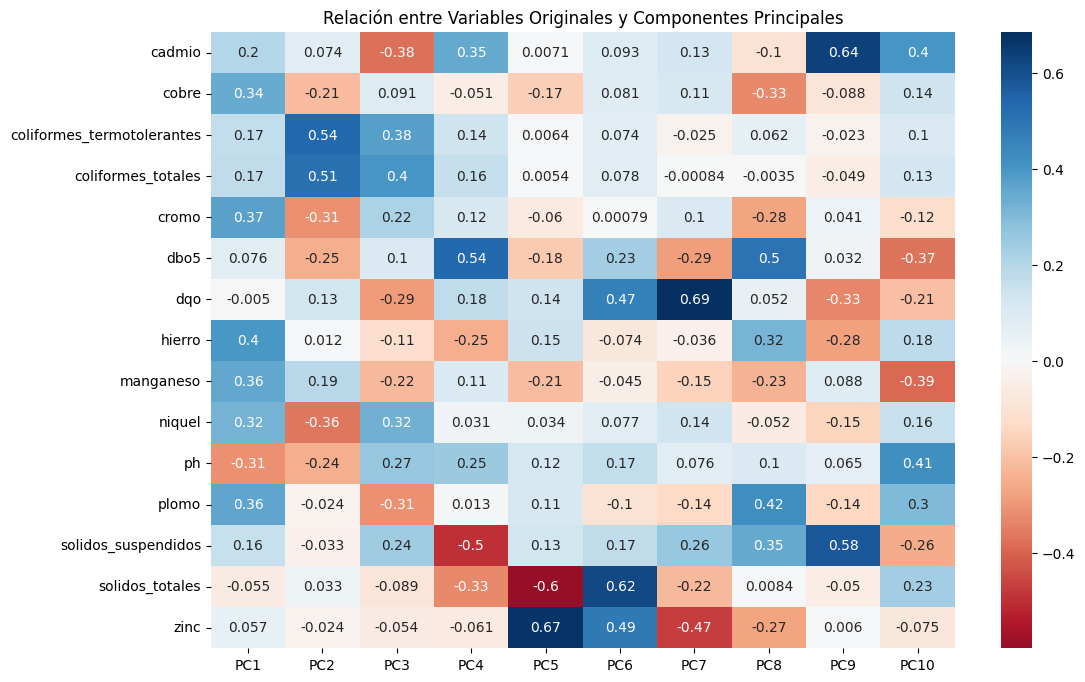

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Relación entre Variables Originales y Componentes Principales')
plt.savefig('./graphs/initial/var_cpa.png')
plt.show()

In [ ]:
# Guardando componentes para pretratamiento
joblib.dump(scaler, '../binary/scaler_obj.joblib')
joblib.dump(pca_converter, '../binary/pca_obj.joblib')

['../binary/pca_obj.joblib']